In [52]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset , DataLoader

## Neuron without activation - Regression/Linear Model

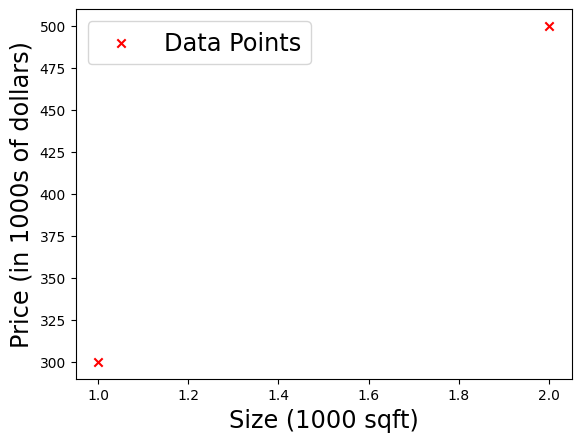

In [53]:
import torch
import matplotlib.pyplot as plt

# Training data
X_train = torch.tensor([[1.0], [2.0]], dtype=torch.float32)
Y_train = torch.tensor([[300.0], [500.0]], dtype=torch.float32)

# Plot
fig, ax = plt.subplots(1, 1)

ax.scatter(
    X_train.numpy(),
    Y_train.numpy(),
    marker='x',
    c='r',
    label='Data Points'
)

ax.legend(fontsize='xx-large')
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large')
ax.set_xlabel('Size (1000 sqft)', fontsize='xx-large')

plt.show()


### Regression/Linear Model 
The function implemented by a neuron with no activation is the same as in Course 1, linear regression:
$$ f_{\mathbf{w},b}(x^{(i)}) = \mathbf{w}\cdot x^{(i)} + b \tag{1}$$



### when we initilaze neuron in Pytorch creates W and B automaticaly and initialize them randomly or we can create them manually as well

##### nn.layer(1,1) -> (1 feature , 1 output)

In [54]:
# now we create a neuron without activation 

layer = nn.Linear(1, 1)

with torch.no_grad():
    layer.weight[:] = torch.tensor([[200.0]])
    layer.bias[:] = torch.tensor([100.0])


In [55]:
#making predictions  

z = layer(X_train)

a = torch.sigmoid(z)

a

tensor([[1.],
        [1.]], grad_fn=<SigmoidBackward0>)

In [56]:
# crearing another data 
X_train = torch.tensor([[0.],[1.],[2.],[3.],[4.],[5.]], dtype=torch.float32)

Y_train = torch.tensor([[0.],[0.],[0.],[1.],[1.],[1.]], dtype=torch.float32)

In [57]:
# making a predicition model with pytorch 

model = nn.Sequential(nn.Linear(1,1) , nn.Sigmoid())

In [58]:
a = model(X_train)
a

tensor([[0.3935],
        [0.4827],
        [0.5730],
        [0.6587],
        [0.7352],
        [0.7997]], grad_fn=<SigmoidBackward0>)

# Optional Lab - Simple Neural Network
In this lab we will build a small neural network using Tensorflow.
   <center> <img  src="/Users/piyush/Repositories/Machine Learning Labs/images/Bildschirmfoto 2026-06-11 um 1.57.39 PM.png" width="400"/>   <center/>
   

In [59]:
# creating a function for making a coffee data
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1,1))

In [60]:
# loding the data
X,Y = load_coffee_data()
X_Pytensor = torch.tensor(X)
Y_Pytensor = torch.tensor(Y)

### As we know that there are 200 rows and 2 features correnspons to 200 target values as well 
### The two features are Temperature in Celsius and Duration in minutes. Coffee Roasting at Home suggests that the duration is best kept between 12 and 15 minutes while the temp should be between 175 and 260 degrees Celsius. Of course, as temperature rises, the duration should shrink.
### And the values of the data is increasing the weight to a larger scale -> which can cause the gradient to run slow 
#### For that feature scaling comes in

In [61]:
print(f"Temperature Max, Min pre normalization: {torch.max(X_Pytensor[:,0]):0.2f}, {torch.min(X_Pytensor[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {torch.max(X_Pytensor[:,1]):0.2f}, {torch.max(X_Pytensor[:,1]):0.2f}")

# Making the normalization layer 
# step 1 caluclating the mean 
mean = X_Pytensor.mean(dim=0) # -> Dimesion -0 means calucalte mean column wise 

# Step-2 calculating the std

std = X_Pytensor.std(dim=0) 

Xn = (X_Pytensor - mean ) / std 

print(f"Temperature Max, Min post normalization: {torch.max(Xn[:,0]):0.2f}, {torch.min(Xn[:,0]):0.2f}")
print(f"Duration Max, Min post normalization: {torch.max(Xn[:,1]):0.2f}, {torch.min(Xn[:,1]):0.2f}")


Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 15.45
Temperature Max, Min post normalization: 1.66, -1.68
Duration Max, Min post normalization: 1.79, -1.70


# Tile/copy our data to increase the training set size and reduce the number of training epochs.

In [62]:
Xt = torch.tile(Xn,(1000,1))
Yt = torch.tile(Y_Pytensor,(1000,1))
Xt = Xt.to(torch.float32)
Yt = Yt.to(torch.float32)
Xt.shape , Yt.shape

(torch.Size([200000, 2]), torch.Size([200000, 1]))

## Tensorflow Model

### Model
   <center> <img  src="/Users/piyush/Repositories/Machine Learning Labs/images/Bildschirmfoto 2026-06-11 um 2.28.13 PM.png" width="900" />   <center/>  
Let's build the "Coffee Roasting Network" described in lecture. There are two layers with sigmoid activations as shown below:

In [63]:
# Ensure the same random values are generated each run

torch.manual_seed(1234)

#  creating the model 

import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 3),  # 2 inputs → 3 neurons
    nn.Sigmoid(),

    nn.Linear(3, 1),  # 3 neurons → 1 output
    nn.Sigmoid()
)


In [64]:
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=3, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=3, out_features=1, bias=True)
  (3): Sigmoid()
)


## After Creating the Model we have to make the function for the prediction in Pytorch 

In [69]:
dataset = TensorDataset(Xt,Yt)

loader = DataLoader(dataset , batch_size=32,shuffle=True)

In [73]:
criterion = nn.BCELoss()
optimizers = torch.optim.Adam(model.parameters(),lr=0.01)

for epoch in range(10):

  for X_batch , Y_batch in loader:
  
    y_pred = model(X_batch)

    loss = criterion(y_pred,Y_batch)

    optimizers.zero_grad()

    loss.backward()

    optimizers.step()

  print(f"Epoch [{epoch+1}/10], Loss: {loss.item():.4f}")



Epoch [1/10], Loss: 0.0000
Epoch [2/10], Loss: 0.0001
Epoch [3/10], Loss: 0.0001
Epoch [4/10], Loss: 0.0000
Epoch [5/10], Loss: 0.0001
Epoch [6/10], Loss: 0.0000
Epoch [7/10], Loss: 0.0000
Epoch [8/10], Loss: 0.0001
Epoch [9/10], Loss: 0.0001
Epoch [10/10], Loss: 0.0001


In [74]:
model.eval()

Sequential(
  (0): Linear(in_features=2, out_features=3, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=3, out_features=1, bias=True)
  (3): Sigmoid()
)

In [75]:
with torch.no_grad():
    predictions = model(Xt)

print(predictions[:5])

tensor([[1.0000e+00],
        [3.2896e-30],
        [6.8108e-11],
        [4.1006e-39],
        [1.0000e+00]])
